# Testing cca for subspace analysis

In [3]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

import pyaldata as pyal
import numpy as np
import matplotlib.pyplot as plt
import scipy

from sklearn.linear_model import LinearRegression

import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt


In [41]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_05_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field VAL_kslabel could not be converted to int.
array field all_kslabel could not be converted to int.
array field SSp_kslabel could not be converted to int.
array field GPe_kslabel could not be converted to int.
array field MOp_kslabel could not be converted to int.
array field CP_kslabel could not be converted to int.
array field VAL_kslabel could not be converted to int.
array field all_kslabel could not be converted to int.
array field SSp_kslabel could not be converted to int.
array field GPe_kslabel could not be converted to int.
array field MOp_kslabel could not be converted to int.
array field CP_kslabel could not be converted to int.
field idx_motion could not be converted to int.
array field VAL_kslabel could not be converted to int.
array field all_kslabel could not be converted to int.
array field SSp_kslabel could not be converted to int.


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

['VAL_spikes', 'all_spikes', 'SSp_spikes', 'GPe_spikes', 'MOp_spikes', 'CP_spikes']


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(


Resulting VAL_spikes ephys data shape is (NxT): (219, 60000)
Resulting all_spikes ephys data shape is (NxT): (24, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (118, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (100, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (155, 60000)
Resulting CP_spikes ephys data shape is (NxT): (195, 60000)


In [42]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=30)


In [33]:
all_kinematics = ['left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip']


df = dt.add_bhv(df, all_kinematics)

In [ ]:
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -50, rel_end= 150)

In [ ]:
from itertools import combinations

def compute_ccs_between_pairs(df, areas):
    fig, ax = plt.subplots(figsize=(10, 4))
    pairs = list(combinations(areas, 2))  # all unique pairs
    for pair in pairs:
        ccs = dim.get_ccs_between_two_areas_from_df(df, pair[0], pair[1])
        ax.plot(ccs, '-o', label=f'{pair[0]} <-> {pair[1]}')
    ax.legend()
    plt.show()

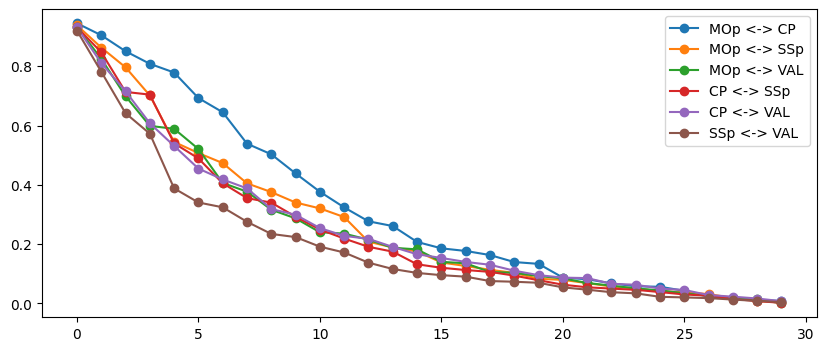

In [28]:
areas = ['MOp', 'CP', 'SSp', 'VAL']
compute_ccs_between_pairs(df, areas)

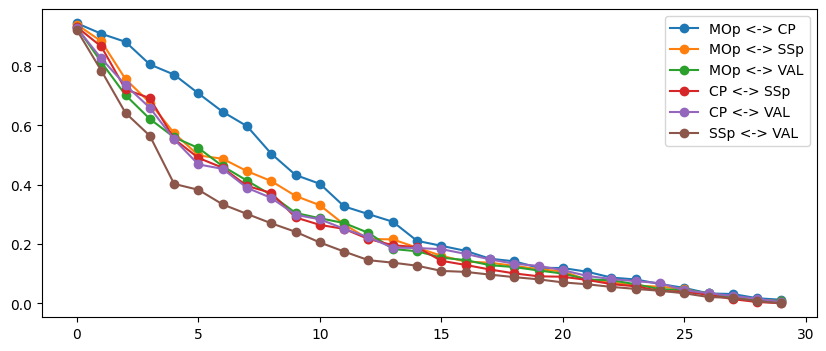

In [44]:
areas = ['MOp', 'CP', 'SSp', 'VAL']
compute_ccs_between_pairs(perturb_td, areas)

## Some decoding

- MOp has the most amount of information about the solenoid direction. It rises earlies with SSp (less info)
- The CP (with a lot of info probably from the descending input of MOp)
- Finally VAL (with even less info)

So, we know that MOp has the most. How much variance of the activity is actually explained by solenoid-specific axes? Like, is all of SSp completely devoted to encoding direction information?

In [69]:
mop_perturb_td = np.stack(perturb_td.MOp_rates_pca.values)
cp_perturb_td = np.stack(perturb_td.CP_rates_pca.values)
val_perturb_td = np.stack(perturb_td.VAL_rates_pca.values)
ssp_perturb_td = np.stack(perturb_td.SSp_rates_pca.values)


targets = trial_df.values_Sol_direction.values.tolist()

In [ ]:
A, B, r, U, V = dim.canoncorr(
    np.concatenate(perturb_td.MOp_rates_pca.values), 
    np.concatenate(perturb_td.CP_rates_pca.values), 
    fullReturn=True
)
mop_cca_cp = U.reshape(mop_perturb_td.shape)
cp_cca_mop = V.reshape(cp_perturb_td.shape)

  0%|          | 0/192 [00:00<?, ?it/s]

100%|██████████| 192/192 [00:01<00:00, 99.60it/s] 


(0.0, 0.55)

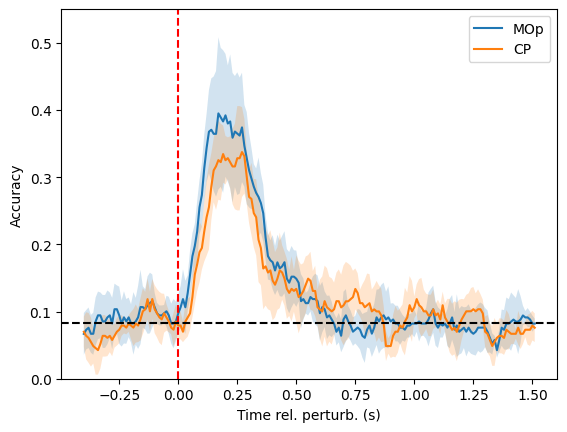

In [65]:
fig, ax = plt.subplots()

scores, times = decode.moving_window_decoding(
        mop_perturb_td,
        targets,
        window_length_bin=10,
        step_bin=1,
        k=5
    )
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, 
                                errorStat=np.std, label='MOp')

scores, times = decode.moving_window_decoding(
        cp_perturb_td,
        targets,
        window_length_bin=10,
        step_bin=1,
        k=5
    )
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, 
                                errorStat=np.std, label='CP')


ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_ylim([0, 0.55])
# ax.set_title()

100%|██████████| 192/192 [00:01<00:00, 100.11it/s]


(0.0, 0.55)

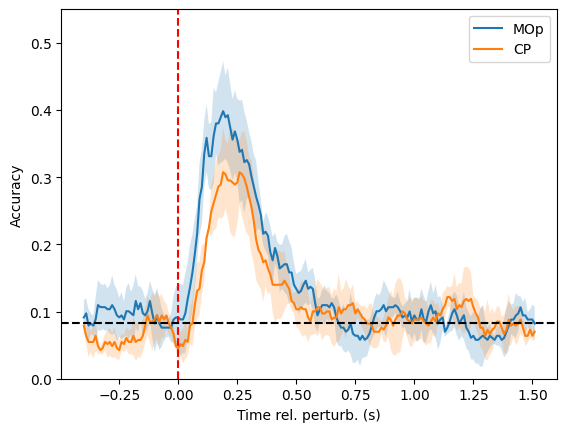

In [66]:
fig, ax = plt.subplots()

scores, times = decode.moving_window_decoding(
        mop_cca_cp,
        targets,
        window_length_bin=10,
        step_bin=1,
        k=5
    )
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, 
                                errorStat=np.std, label='MOp')

scores, times = decode.moving_window_decoding(
        cp_cca_mop,
        targets,
        window_length_bin=10,
        step_bin=1,
        k=5
    )
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, 
                                errorStat=np.std, label='CP')


ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_ylim([0, 0.55])
# ax.set_title()

In [70]:
A, B, r, U, V = dim.canoncorr(
    np.concatenate(perturb_td.MOp_rates_pca.values), 
    np.concatenate(perturb_td.VAL_rates_pca.values), 
    fullReturn=True
)
mop_cca_val = U.reshape(mop_perturb_td.shape)
val_cca_mop = V.reshape(val_perturb_td.shape)

100%|██████████| 192/192 [00:01<00:00, 98.58it/s]


(0.0, 0.55)

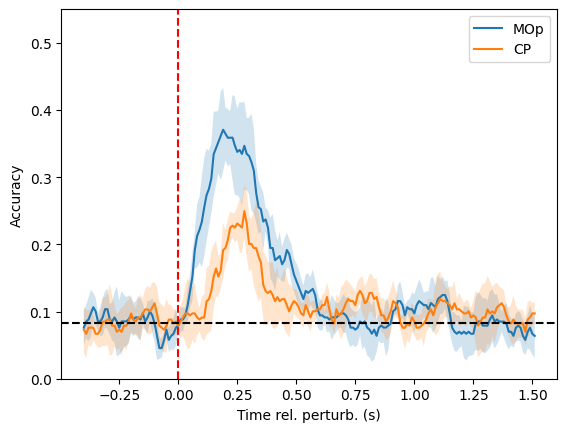

In [71]:
fig, ax = plt.subplots()

scores, times = decode.moving_window_decoding(
        mop_cca_val,
        targets,
        window_length_bin=10,
        step_bin=1,
        k=5
    )
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, 
                                errorStat=np.std, label='MOp')

scores, times = decode.moving_window_decoding(
        val_cca_mop,
        targets,
        window_length_bin=10,
        step_bin=1,
        k=5
    )
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, 
                                errorStat=np.std, label='CP')


ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_ylim([0, 0.55])
# ax.set_title()

100%|██████████| 192/192 [00:01<00:00, 98.80it/s] 


(0.0, 0.55)

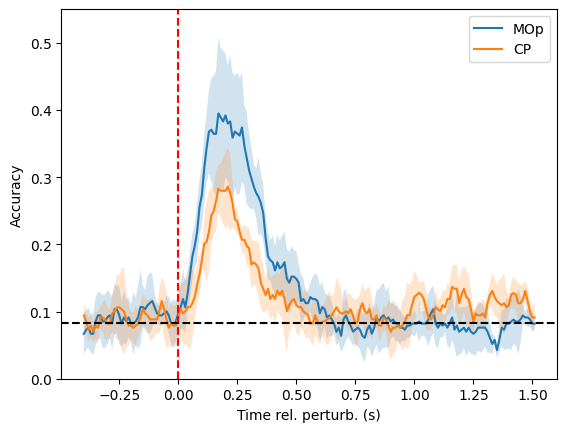

In [72]:
fig, ax = plt.subplots()

scores, times = decode.moving_window_decoding(
        mop_perturb_td,
        targets,
        window_length_bin=10,
        step_bin=1,
        k=5
    )
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, 
                                errorStat=np.std, label='MOp')

scores, times = decode.moving_window_decoding(
        ssp_perturb_td,
        targets,
        window_length_bin=10,
        step_bin=1,
        k=5
    )
line, _ = vizutils.shaded_errorbar(ax, times-0.5, scores, 
                                errorStat=np.std, label='CP')


ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_ylim([0, 0.55])
# ax.set_title()

## Some dPCA to see how much of each area is devoted to encoding solenoid direction

In [6]:


# number of neurons, time-points and stimuli
N,T,S = 100,250,6

# noise-level and number of trials in each condition
noise, n_samples = 0.2, 10

# build two latent factors
zt = (np.arange(T)/float(T))
zs = (np.arange(S)/float(S))

# build trial-by trial data
trialR = noise*np.random.randn(n_samples,N,S,T)
trialR += np.random.randn(N)[None,:,None,None]*zt[None,None,None,:]
trialR += np.random.randn(N)[None,:,None,None]*zs[None,None,:,None]

# trial-average data
R = np.mean(trialR,0)

# center data
R -= np.mean(R.reshape((N,-1)),1)[:,None,None] 

In [8]:
from dPCA import dPCA
dpca = dPCA.dPCA(labels='st',regularizer='auto')
dpca.protect = ['t']

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.


In [9]:
Z = dpca.fit_transform(R,trialR)

Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.000449987958058483
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.


In [22]:
Z['st'].shape

(10, 6, 250)

Text(0.5, 1.0, 'time-target')

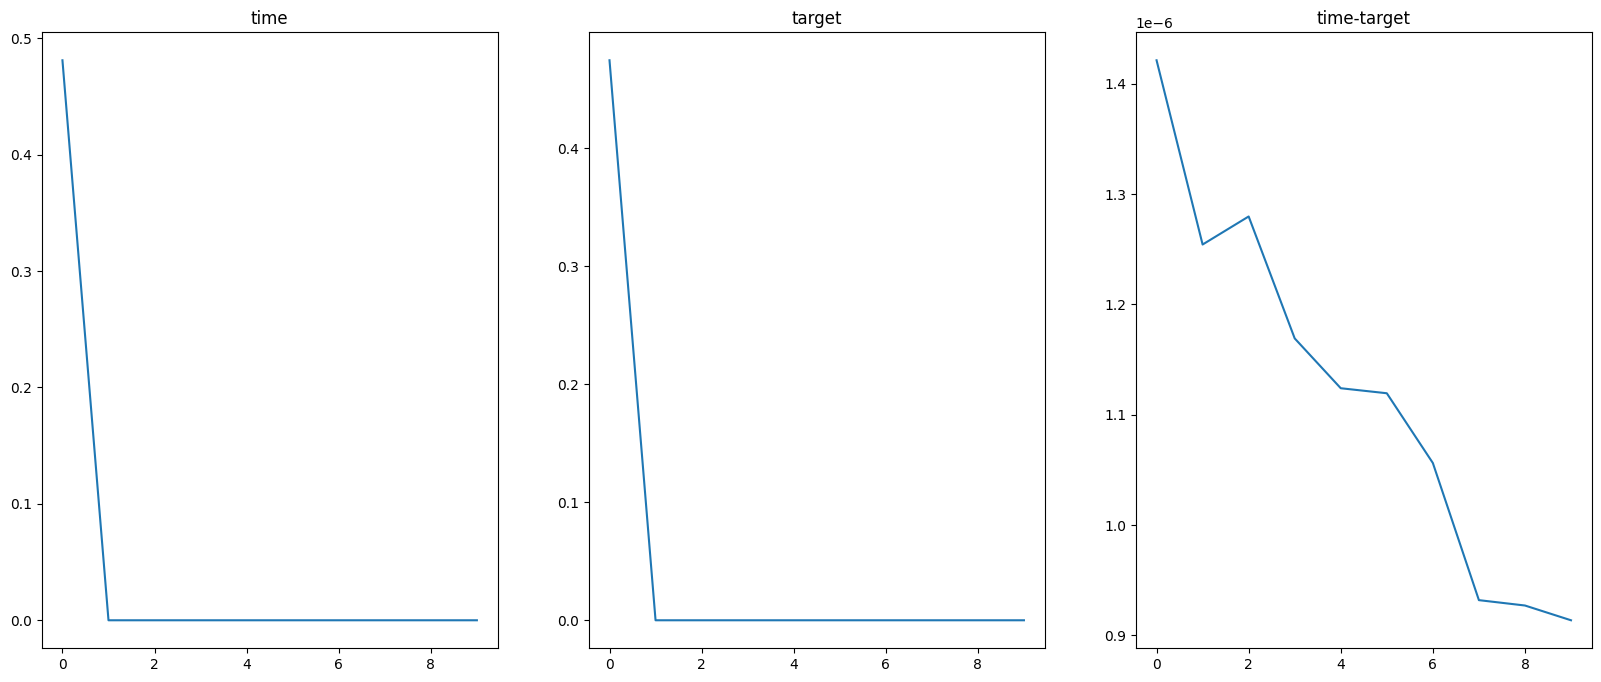

In [19]:
# %%
explained_variance_ratios = dpca.explained_variance_ratio_

# %%
fig, ax = plt.subplots(figsize = (20, 8), ncols = 3)
ax[0].plot(explained_variance_ratios['t'])
ax[1].plot(explained_variance_ratios['s'])
ax[2].plot(explained_variance_ratios['st'])

ax[0].set_title('time')
ax[1].set_title('target')
ax[2].set_title('time-target')


## Check allignment in the intertrial period vs trial?

In [15]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_05_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field VAL_kslabel could not be converted to int.
array field all_kslabel could not be converted to int.
array field SSp_kslabel could not be converted to int.
array field GPe_kslabel could not be converted to int.
array field MOp_kslabel could not be converted to int.
array field CP_kslabel could not be converted to int.
array field VAL_kslabel could not be converted to int.
array field all_kslabel could not be converted to int.
array field SSp_kslabel could not be converted to int.
array field GPe_kslabel could not be converted to int.
array field MOp_kslabel could not be converted to int.
array field CP_kslabel could not be converted to int.
field idx_motion could not be converted to int.
array field VAL_kslabel could not be converted to int.
array field all_kslabel could not be converted to int.
array field SSp_kslabel could not be converted to int.


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

['VAL_spikes', 'all_spikes', 'SSp_spikes', 'GPe_spikes', 'MOp_spikes', 'CP_spikes']


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(


Resulting VAL_spikes ephys data shape is (NxT): (219, 60000)
Resulting all_spikes ephys data shape is (NxT): (24, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (118, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (100, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (155, 60000)
Resulting CP_spikes ephys data shape is (NxT): (195, 60000)


In [16]:
df = dt.add_pca_df(df_, n_components=30)
trial_df = pyal.select_trials(df, df.trial_name == 'trial')
intertrial_df = pyal.select_trials(df, df.trial_name == 'intertrial')
perturb_td = pyal.restrict_to_interval(trial_df, 'idx_sol_on', rel_start = -50, rel_end= 150)


In [38]:
ccs_perturb = []
for _, row in perturb_td.iterrows():
    ccs_perturb.append(dim.canoncorr(row['MOp_rates_pca'], row["CP_rates_pca"]))
ccs_perturb = np.array(ccs_perturb)

ccs_inter= []
for _, row in intertrial_df.iterrows():
    ccs_inter.append(dim.canoncorr(row['MOp_rates_pca'], row["CP_rates_pca"]))
ccs_inter = np.array(ccs_inter)

(<matplotlib.lines.Line2D at 0x7886181fb140>,
 <matplotlib.collections.FillBetweenPolyCollection at 0x788617d19970>)

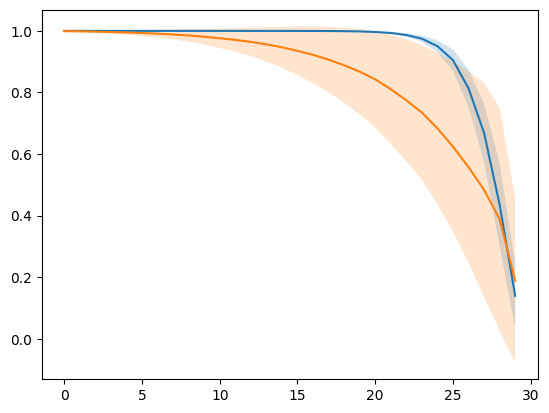

In [ ]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, ccs_perturb.T)
vizutils.shaded_errorbar(ax, ccs_inter.T)



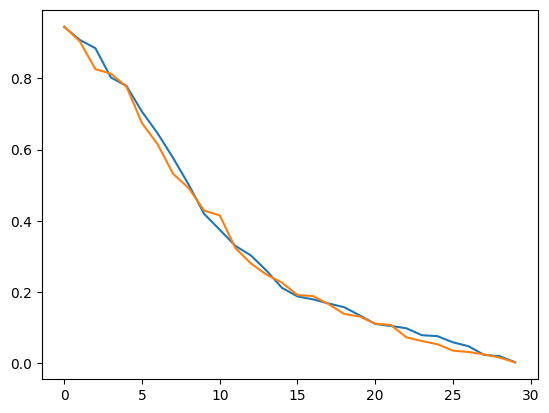

In [44]:
plt.plot(dim.get_ccs_between_two_areas_from_df(
    perturb_td, "MOp", "CP"
))

plt.plot(dim.get_ccs_between_two_areas_from_df(
    intertrial_df, "MOp", "CP"
))
plt.show()

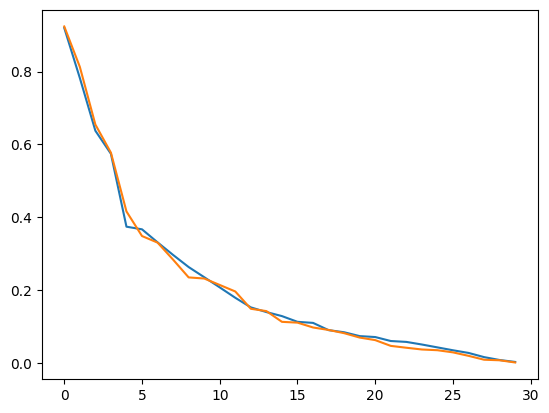

In [45]:
plt.plot(dim.get_ccs_between_two_areas_from_df(
    perturb_td, "SSp", "VAL"
))

plt.plot(dim.get_ccs_between_two_areas_from_df(
    intertrial_df, "SSp", "VAL"
))
plt.show()

In [40]:
ccs_perturb = []
for _, row in perturb_td.iterrows():
    ccs_perturb.append(dim.canoncorr(row['SSp_rates_pca'], row["VAL_rates_pca"]))
ccs_perturb = np.array(ccs_perturb)

ccs_inter= []
for _, row in intertrial_df.iterrows():
    ccs_inter.append(dim.canoncorr(row['SSp_rates_pca'], row["VAL_rates_pca"]))
ccs_inter = np.array(ccs_inter)

(<matplotlib.lines.Line2D at 0x7886185f60c0>,
 <matplotlib.collections.FillBetweenPolyCollection at 0x7886185f5e20>)

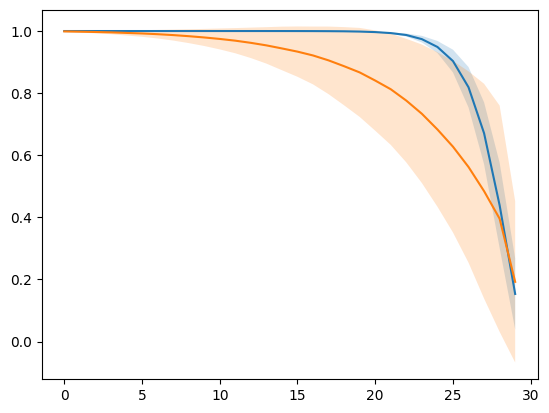

In [41]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, ccs_perturb.T)
vizutils.shaded_errorbar(ax, ccs_inter.T)
